<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB37 · Fuerza, par y el péndulo de verdad

**Parte 5 · La física del cuerpo — Lección 2**

> En el **NB36** aprendiste a **describir** la postura de un robot: ángulos, senos y cosenos, y dónde queda el pie. Pero describir no es explicar. ¿Qué es lo que **cambia** la postura? ¿Por qué un robot se cae?

La respuesta corta: las **fuerzas**. Hoy vamos a convertir la física de palabras del NB02 en física **con números**, y la vamos a usar para resolver una deuda pendiente.

¿Te acuerdas del palo de escoba del **NB11**? Su "física de juguete" decía:

```
   aceleración de giro  =  10 × inclinación  +  empuje del motor  +  viento
```

y te dije que **no** era la física exacta de una escoba, que esa "necesita matemáticas que aún no hemos visto". Ya las has visto (el seno, NB36). Al final de este notebook habrás **deducido tú** la física de verdad de un palo que se cae, sabrás de dónde sale ese **10**, y la comprobarás contra MuJoCo.

Por el camino aparecerán tres ideas que cualquier ingeniero de robots usa a diario: la **segunda ley de Newton**, el **par** (la fuerza de los motores) y la **inercia de giro**.


## 1 · Primero, las unidades

En física, un número **sin unidad** no significa nada. "Mide 3" ¿qué? ¿3 metros, 3 centímetros, 3 kilómetros? Los científicos de todo el mundo usan las mismas unidades básicas (el **Sistema Internacional**), y MuJoCo también:

| Qué se mide | Unidad | Símbolo |
|---|---|---|
| Distancia | metro | m |
| Tiempo | segundo | s |
| Masa (cuánta "materia" tiene algo) | kilogramo | kg |

Y de ahí salen las demás, **combinándolas**:

- **Velocidad**: cuántos metros avanzas **cada** segundo: **metros por segundo**, m/s. (Hopper iba a 2,67 m/s en el NB35.)
- **Aceleración**: cuánto **cambia** tu velocidad cada segundo. Si cada segundo vas 10 m/s más deprisa, tu aceleración es de 10 "metros por segundo, por segundo": **m/s²** (se lee "metros por segundo al cuadrado").

Y para los giros, lo mismo pero con ángulos (en radianes, NB36):

- **Velocidad de giro** (o **angular**): radianes por segundo, **rad/s**.
- **Aceleración de giro** (o **angular**): cuánto cambia la velocidad de giro cada segundo, **rad/s²**.

Un truco que usan todos los ingenieros: si al final de una cuenta las unidades no cuadran (te sale "metros" cuando calculabas un tiempo), **la cuenta está mal**. Las unidades son un detector de errores gratis. Recuerda el `math.sin(90)` del NB36: un error de unidades que no avisó.


## 2 · La segunda ley de Newton

En el NB02 vimos la **cadena de oro**:

```
     FUERZA  ───cambia───►  VELOCIDAD  ───cambia───►  POSICIÓN
```

y dos ideas sin números: una fuerza **acelera** las cosas, y cuanto más **masa** tienen, **menos** las acelera la misma fuerza (es más fácil empujar un carrito vacío que uno lleno).

Isaac Newton lo convirtió en una fórmula, la más famosa de la física:

```
   aceleración  =  fuerza  ÷  masa            (a = F / m)
```

Que se suele escribir al revés, **F = m × a**, pero dice lo mismo. Léela así: **la misma fuerza acelera la mitad a algo que pesa el doble**.

Para que la fórmula funcione hace falta una unidad de fuerza. En su honor se llama **newton** (N): **un newton es la fuerza que acelera 1 kg a 1 m/s²**. Para hacerte una idea, sostener una manzana pequeña en la mano es hacer más o menos **1 newton** de fuerza.

Hagamos una cuenta. Empujas un carrito de supermercado de **20 kg** con una fuerza de **30 N**. ¿Cuánto se acelera?


In [1]:
masa = 20          # kg
fuerza = 30        # N
aceleracion = fuerza / masa
print(aceleracion, "m/s²")

1.5 m/s²


**1,5 m/s²**: cada segundo que sigas empujando, el carrito irá 1,5 m/s más deprisa. Y ahora el mismo empujón con el carrito **lleno**, de 60 kg:

In [2]:
print(30 / 60, "m/s²")

0.5 m/s²


El triple de masa, un tercio de aceleración: **0,5 m/s²**. La inercia del NB02, en números.


## 3 · El peso: la fuerza de la gravedad

En el NB02 dijimos que la gravedad hace que cualquier cosa que cae gane unos **10 m/s** de velocidad cada segundo. Con las unidades de hoy: la gravedad acelera todo hacia abajo a **9,81 m/s²**. A ese número se le llama **g**.

Y si la aceleración es g, por la segunda ley, la **fuerza** con la que la gravedad tira de algo es su masa por g. A esa fuerza la llamamos **peso**:

```
   peso  =  masa  ×  g          (en newtons)
```

(Fíjate: en la calle decimos "peso 60 kilos", pero para un físico eso es tu **masa**. Tu **peso** es la fuerza con la que la Tierra tira de ti: 60 × 9,81 ≈ 589 N. En la Luna tendrías la misma masa, pero pesarías seis veces menos.)

¿Cuánto pesa Hopper, que tiene una masa de 15,8 kg (NB35)?


In [3]:
g = 9.81
print(round(15.8 * g), "N")

155 N


**155 newtons**, todo el rato, tirando de él hacia abajo.

### Fuerzas que se compensan

Pero entonces, ¿por qué Hopper, de pie y quieto, **no** acelera hacia abajo? Porque hay **otra** fuerza: el **suelo** empuja su pie **hacia arriba** (es el "choque" del NB02: el suelo no se deja atravesar). Si ese empujón es exactamente igual al peso, las dos fuerzas se **anulan**:

```
            ▲  155 N  (el suelo empuja hacia arriba)
            │
            ●  Hopper
            │
            ▼  155 N  (la gravedad tira hacia abajo)

     fuerza total = 155 − 155 = 0  →  aceleración 0  →  se queda quieto
```

Las fuerzas son **flechas** (vectores, NB12): tienen tamaño y dirección, y se **suman** como flechas. Lo que acelera un objeto no es cada fuerza por separado, sino la **suma** de todas. Si la suma es cero, el objeto sigue haciendo lo que hacía (la inercia del NB02). A la fuerza con la que el suelo empuja se le llama **fuerza normal** ("normal" aquí significa "perpendicular al suelo").

Esto es lo que mide un **sensor de fuerza** en el pie de un robot real (lo veremos en el NB41): cuánto empuja el suelo. Si el robot está quieto y apoyado en un pie, ese sensor marca **su peso**.


## 4 · El par: la fuerza que hace girar

Hasta ahora, fuerzas que **empujan en línea recta**. Pero las articulaciones de un robot no se desplazan: **giran**. Y para hacer girar algo no basta con saber cuánta fuerza haces. Importa **dónde** la haces.

Prueba esto con una puerta de verdad:

- Empújala por el **pomo**, lejos de las bisagras: se abre con un dedo.
- Empújala a **un palmo** de las bisagras: cuesta muchísimo más.
- Empújala **justo en las bisagras**: no se abre, por mucho que empujes.

La misma fuerza produce más o menos **giro** según **lo lejos del eje** que la apliques. A esa "capacidad de hacer girar" se le llama **par** (o **momento**, o en inglés **torque**). Ya salió en el NB01 como el "par de giro" de los motores. Su fórmula:

```
   par  =  fuerza  ×  brazo
```

donde el **brazo** (o **brazo de palanca**) es la **distancia** del eje al punto donde empujas. Su unidad es el **newton metro** (newton multiplicado por metro): **N·m**.

```
     bisagra                          pomo
        ●─────────────────────────────●
        │◄──────── brazo: 0,8 m ─────►│
                                      ▲
                                      │ 10 N
```

Empujar con 10 N en el pomo, a 0,8 m:


In [4]:
print(10 * 0.8, "N·m")

8.0 N·m


**8 N·m**. Para conseguir el mismo par empujando a 0,1 m de la bisagra, harían falta **80 N**: ocho veces más fuerza. Por eso una **llave inglesa** larga afloja tuercas que con los dedos no puedes: alarga el brazo. Es la **palanca** de Arquímedes: "dadme un punto de apoyo y moveré el mundo".


### Cuando la fuerza no empuja de lado

Falta un detalle. Si empujas la puerta por el pomo pero **hacia las bisagras** (a lo largo de la puerta, no de lado), no gira nada, por mucha fuerza que hagas. Solo cuenta la parte de la fuerza que empuja **de lado**, perpendicular a la puerta.

¿Y cómo se calcula "la parte de lado"? ¡Con el **seno** del NB36! Si la fuerza forma un ángulo φ ("fi", otra letra griega) con la puerta:

```
   par  =  fuerza  ×  brazo  ×  sin φ
```

- φ = 90° (empujas de lado, perpendicular): sin 90° = 1, todo el empujón cuenta.
- φ = 0° (empujas a lo largo de la puerta): sin 0° = 0, nada de giro.
- Ángulos intermedios: una parte.

Los mismos 10 N en el pomo, pero empujando en diagonal (45°):


In [5]:
import math

print(round(10 * 0.8 * math.sin(math.radians(45)), 2), "N·m")

5.66 N·m


**5,66 N·m** en vez de 8: el 71 % del empujón (sin 45° = 0,707, NB36) hace girar; el resto solo aprieta la puerta contra sus bisagras.


## 5 · El par de la gravedad sobre un palo inclinado

Ahora, el palo de escoba. Imagina un palo de largo **L** y masa **m**, apoyado por su extremo de abajo en un punto fijo (tu mano, o una bisagra), e inclinado un ángulo **θ** desde la vertical.

La gravedad tira de **todos** los trocitos del palo. Pero hay un truco que simplifica muchísimo: para calcular su efecto, podemos hacer como si todo el peso estuviera concentrado en un solo punto, el **centro de masas** (NB01). En un palo uniforme, el centro de masas está **justo en la mitad**, a L/2 del extremo. (Este truco lo estudiaremos a fondo en el NB38.)

```
                        ●  punta
                       ╱
                      ╱
                     ✚  ← centro de masas, a L/2 del apoyo
                    ╱│
                   ╱ │
                  ╱θ │ peso = m × g  (siempre hacia ABAJO)
                 ●   ▼
              apoyo
```

El peso es una fuerza de m × g que tira **hacia abajo**, aplicada a L/2 del apoyo. ¿Qué ángulo forma con el palo? Si el palo está inclinado θ desde la vertical, el peso (que **es** vertical) forma con él justo el ángulo θ. Así que, con la fórmula de la sección anterior:

```
   par de la gravedad  =  m × g  ×  (L / 2)  ×  sin θ
```

Fíjate en lo que dice:

- **Palo recto** (θ = 0): sin 0 = 0, **par cero**. La gravedad tira, pero a lo largo del palo, y no lo hace girar. Es el equilibrio perfecto... e inestable, como vimos en el NB00.
- **Un poco inclinado**: un poco de par, que lo inclina **más**.
- **Más inclinado**: más par. Y cuanto más se inclina, más par: por eso la caída se acelera.
- **Horizontal** (θ = 90°): par máximo.

Calculémoslo para un palo de 1,5 m y 1 kg:


In [6]:
masa_palo = 1.0
largo_palo = 1.5

def par_gravedad(theta):
    return masa_palo * g * (largo_palo / 2) * math.sin(theta)

In [7]:
for grados in [0, 5, 30, 90]:
    print(f"{grados:2d}°: {par_gravedad(math.radians(grados)):5.2f} N·m")

 0°:  0.00 N·m
 5°:  0.64 N·m
30°:  3.68 N·m
90°:  7.36 N·m


De **0** recto a **7,36 N·m** tumbado. Y fíjate en los 5°: ya hay 0,64 N·m tirando del palo hacia el suelo. El palo de escoba nunca está "tranquilo" salvo en el 0 exacto.


## 6 · La inercia de giro

Con la segunda ley de Newton (sección 2) sabemos que una fuerza **acelera** según la **masa**. Para los giros hay una ley gemela: un **par** produce una **aceleración de giro**... según algo parecido a la masa, pero no igual. Se llama **inercia de giro** (o **momento de inercia**), y se escribe **I**.

¿Por qué no basta con la masa? Haz este experimento mental:

- Coge una **escoba** por el palo, cerca del cepillo, y gírala de un lado a otro (como un limpiaparabrisas). Fácil.
- Ahora cógela por el **otro extremo**, con el cepillo lejos de tu mano, y haz lo mismo. ¡Cuesta mucho más!

La escoba tiene **la misma masa** en los dos casos. Lo que cambia es **dónde está la masa respecto del eje** de giro (tu mano). La masa **lejos** del eje cuesta mucho más de girar que la masa cerca.

El ejemplo clásico es una **patinadora** sobre hielo girando sobre sí misma: con los brazos **abiertos** gira despacio; al **recogerlos**, acerca su masa al eje y de repente gira mucho más deprisa.

¿Cuánto más cuesta la masa lejana? La regla exacta es: cada trocito de masa cuenta **su masa por su distancia al eje, al cuadrado**:

```
   inercia de giro  =  suma de  (masa de cada trocito  ×  distancia al eje²)
```

Al cuadrado: un trocito al **doble** de distancia cuesta **cuatro** veces más de girar. Su unidad es kg·m².


### La inercia del palo, a trocitos

Calculémosla para nuestro palo de 1,5 m y 1 kg, girando sobre su extremo, **literalmente** con la regla: lo cortamos en **1.000 trocitos** iguales, y sumamos "masa × distancia²" de todos. Con NumPy (NB15) es una línea por idea. Primero, dónde está cada trocito (la mitad de cada uno):


In [8]:
import numpy as np

n_trocitos = 1000
largo_trocito = largo_palo / n_trocitos
distancias = (np.arange(n_trocitos) + 0.5) * largo_trocito
print(distancias[:3], "...", distancias[-1])

[0.00075 0.00225 0.00375] ... 1.49925


(`np.arange(1000)` da 0, 1, 2... 999; sumándole 0,5 y multiplicando por el largo de cada trocito sale el centro de cada uno, de 0,00075 m a 1,49925 m.) Cada trocito tiene una milésima de la masa:

In [9]:
masa_trocito = masa_palo / n_trocitos
inercia = np.sum(masa_trocito * distancias ** 2)
print(round(inercia, 4), "kg·m²")

0.75 kg·m²


**0,75 kg·m²**. Los matemáticos han hecho esta suma con infinitos trocitos infinitamente pequeños (con una herramienta llamada **integral**, prima de la derivada del NB16) y han encontrado una fórmula exacta para un palo que gira sobre un extremo:

```
   inercia de giro de un palo  =  m × L² / 3
```

Comprobémosla: 1 × 1,5² / 3 = 0,75. ¡La misma que con nuestros mil trocitos!


In [10]:
print(masa_palo * largo_palo ** 2 / 3)

0.75


## 7 · Newton para giros, y la ecuación de la escoba

La ley gemela de la segunda ley de Newton, para giros, es:

```
   aceleración de giro  =  par  ÷  inercia de giro          (α = par / I)
```

(α, "alfa", es la letra que se usa para la aceleración de giro.) Exactamente como a = F / m, cambiando fuerza por par y masa por inercia de giro.

Ya tenemos **todas** las piezas del palo de escoba:

- el par de la gravedad: m × g × (L/2) × sin θ;
- la inercia de giro: m × L² / 3.

Dividimos:

```
          m × g × (L/2) × sin θ
   α  =  ───────────────────────
               m × L² / 3
```

Y ahora simplificamos, como en las fracciones del colegio: la **m** está arriba y abajo, así que **se va**. Una **L** de arriba se va con una de las dos de abajo. Y dividir entre 2 y entre "un tercio" es multiplicar por 3/2. Queda:

```
   α  =  (3 × g ÷ (2 × L))  ×  sin θ
```

Esta es **la ecuación de un palo que se cae**. La física de verdad. Mírala bien, porque dice dos cosas sorprendentes.


### Sorpresa 1: la masa no importa

¡La **m** ha desaparecido! Un palo de escoba de madera y uno de hierro, del mismo largo, se caen **exactamente igual de deprisa**. La gravedad tira más del pesado, pero al pesado también le cuesta más girar, y las dos cosas se compensan justo. Es la misma idea que descubrió **Galileo** dejando caer bolas de distinto peso: sin aire, caen a la vez.

### Sorpresa 2: el largo sí importa, y mucho

La **L** está **dividiendo**: cuanto más **largo** el palo, **más despacio** se cae. Por eso es mucho más fácil sostener una **escoba** en equilibrio sobre la mano que un **lápiz**: el lápiz se cae tan deprisa que no te da tiempo a reaccionar. Calculemos el "número de la caída" (lo que multiplica a sin θ) para los dos:


In [11]:
def numero_de_caida(largo):
    return 3 * g / (2 * largo)

print("escoba (1,5 m): ", round(numero_de_caida(1.5), 1))
print("lápiz (0,15 m): ", round(numero_de_caida(0.15), 1))

escoba (1,5 m):  9.8
lápiz (0,15 m):  98.1


El del lápiz es **diez veces** mayor: se cae muchísimo más deprisa. Esto es importante para los robots: un robot **alto** es, en cierto sentido, más **fácil** de equilibrar que uno bajito, porque se cae más despacio y deja más tiempo para corregir. (Hay más cosas en juego, como veremos en el NB39, pero esta idea es real.)


### El misterioso 10 del NB11

Y ahora, la deuda pendiente. La física de juguete del NB11 decía: "aceleración de giro = **10** × inclinación". La de verdad dice: "aceleración de giro = **(3g / 2L)** × **sin** θ". Hay dos diferencias:

**1. El número.** En el NB11 era 10; en la de verdad es 3g / (2L). ¿Para qué largo de palo sale justo 10? Despejamos: L = 3g / (2 × 10):


In [12]:
print(round(3 * g / (2 * 10), 2), "m")

1.47 m


**1,47 metros**: ¡el largo de una escoba de verdad! El 10 no era un número al azar: es lo que corresponde a una escoba normal.

**2. El seno.** En el NB11 ponía **inclinación**, y aquí, **sin θ**. Pero en el NB36 (sección 7) vimos que, para ángulos **pequeños**, sin θ es casi igual a θ (en radianes):


In [13]:
for theta in [0.05, 0.2, 0.5, 1.0]:
    print(f"θ = {theta:4.2f} rad   sin θ = {math.sin(theta):.4f}   diferencia: {100 * (theta - math.sin(theta)) / math.sin(theta):4.1f} %")

θ = 0.05 rad   sin θ = 0.0500   diferencia:  0.0 %
θ = 0.20 rad   sin θ = 0.1987   diferencia:  0.7 %
θ = 0.50 rad   sin θ = 0.4794   diferencia:  4.3 %
θ = 1.00 rad   sin θ = 0.8415   diferencia: 18.8 %


Con 0,05 radianes (3°), la diferencia es del 0,04 %: nada. Con 0,2 (11°), del 0,7 %. Con 0,5 (29°, cerca del límite de caída del NB11), del 4 %. Solo con ángulos grandes, como 1 radián (57°), la diferencia es importante (19 %). El palo del NB11 se daba por caído a los 30°, así que casi siempre estaba en la zona en la que **θ y sin θ son prácticamente lo mismo**.

Es decir: la física de juguete del NB11 era la física de verdad de una escoba de 1,47 m, con una simplificación (sin θ ≈ θ) que casi no se nota en los ángulos en los que trabajaba. A esta simplificación se le llama **linealizar** ("hacer recta" una curva cerca de un punto, como el zoom del NB16). Los ingenieros de control la usan **constantemente**, porque con fórmulas lineales todo es más fácil de calcular.


## 8 · Simulemos la caída de verdad

Usemos la cadena de oro del NB07 (aceleración → velocidad → posición, a pasitos pequeños) para ver caer el palo de 1,5 m, con la física de verdad (con seno) y con la linealizada (sin seno). Empieza **casi** recto, inclinado 0,05 radianes, y quieto. Pasitos de 1 milésima de segundo:


In [14]:
def caida(largo, con_seno, theta_inicial=0.05, hasta=math.pi / 2, paso=0.001):
    theta, velocidad, t = theta_inicial, 0.0, 0.0
    tiempos, angulos = [t], [theta]
    while theta < hasta:
        if con_seno:
            aceleracion = numero_de_caida(largo) * math.sin(theta)
        else:
            aceleracion = numero_de_caida(largo) * theta
        velocidad = velocidad + aceleracion * paso       # aceleración → velocidad
        theta = theta + velocidad * paso                 # velocidad → ángulo
        t = t + paso
        tiempos.append(t)
        angulos.append(theta)
    return tiempos, angulos

La función repite pasitos hasta que el palo llega a `hasta` (por defecto π/2, es decir, horizontal: en el suelo), y devuelve la lista de tiempos y de ángulos. Las dos versiones:

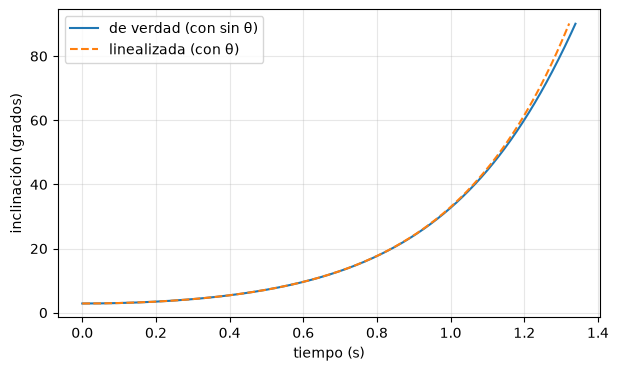

tarda en llegar al suelo: 1.339 s (de verdad) | 1.322 s (linealizada)


In [15]:
import matplotlib.pyplot as plt

t_seno, a_seno = caida(1.5, con_seno=True)
t_lineal, a_lineal = caida(1.5, con_seno=False)

plt.figure(figsize=(7, 4))
plt.plot(t_seno, np.degrees(a_seno), label="de verdad (con sin θ)")
plt.plot(t_lineal, np.degrees(a_lineal), "--", label="linealizada (con θ)")
plt.xlabel("tiempo (s)")
plt.ylabel("inclinación (grados)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"tarda en llegar al suelo: {t_seno[-1]:.3f} s (de verdad) | {t_lineal[-1]:.3f} s (linealizada)")

Las dos curvas van **pegadas** durante casi todo el camino: el palo pasa más de **medio segundo** inclinándose poquito a poco (de 3° a unos 10°: casi no se nota que se cae), y después, en apenas siete décimas, se desploma hasta el suelo. Esa es la **inestabilidad**: lo que empieza como una inclinación invisible acaba en el suelo, y cada vez más deprisa.

Solo al final, con ángulos grandes, se separan: la linealizada cae un poquito **antes**, porque θ es algo mayor que sin θ y exagera la gravedad. La diferencia final es de unas centésimas de segundo.


## 9 · El examen: un péndulo de MuJoCo

Hemos deducido la física con papel y lápiz. ¿Hace MuJoCo lo mismo? Vamos a construirle un palo **exactamente** como el nuestro (1,5 m, 1 kg, muy delgado, con una bisagra en el extremo de abajo) y a dejarlo caer.

Para eso hay que escribir su "plano" en el lenguaje de MuJoCo, que se llama **MJCF**. Lo estudiaremos a fondo en el NB42 (ahí construirás robots enteros); por hoy, basta con leerlo como una lista de piezas:


In [16]:
import mujoco

plano = '''
<mujoco>
  <option timestep="0.001"/>
  <worldbody>
    <body>
      <joint type="hinge" axis="0 1 0"/>
      <geom type="cylinder" fromto="0 0 0  0 0 1.5" size="0.005" mass="1"/>
    </body>
  </worldbody>
</mujoco>
'''

Se lee así:

- `option timestep="0.001"`: pasitos de 1 milésima de segundo, como los nuestros.
- `body`: una pieza.
- `joint type="hinge"`: unida al mundo con una **bisagra** (NB01) que gira alrededor del eje y (`axis="0 1 0"`), para que caiga en el plano, como Hopper.
- `geom type="cylinder"`: su forma es un **cilindro** que va **de** (0, 0, 0) **a** (0, 0, 1,5): un palo vertical de 1,5 m, de 5 mm de radio (muy delgado), con 1 kg de masa.

(Las tres comillas simples `'''` hacen un texto de varias líneas, como las dobles del NB20.) Ahora MuJoCo lee el plano y crea el modelo (`model`) y su estado (`data`), como los del NB36:


In [17]:
modelo = mujoco.MjModel.from_xml_string(plano)
datos = mujoco.MjData(modelo)

Primero, una pregunta: ¿qué inercia de giro le calcula MuJoCo al palo? MuJoCo la guarda **respecto del centro de masas** (en `body_inertia`), así que para tenerla respecto del extremo hay que sumarle m × (L/2)² (una regla que se llama "teorema de Steiner": girar alrededor de un punto que no es el centro cuesta eso más):

In [18]:
inercia_centro = modelo.body_inertia[1][0]        # pieza 1 (la 0 es el mundo), eje de giro
print(round(inercia_centro + masa_palo * (largo_palo / 2) ** 2, 4), "kg·m²")

0.75 kg·m²


**0,75**: la misma que con nuestros mil trocitos y con la fórmula m × L² / 3. Ahora, a dejarlo caer desde 0,05 radianes hasta el suelo (π/2), contando el tiempo. `mujoco.mj_step` avanza la simulación **un** pasito (es lo que hace `env.step` por dentro, varias veces):

In [19]:
datos.qpos[0] = 0.05             # inclinación inicial
tiempo = 0.0
while datos.qpos[0] < math.pi / 2:
    mujoco.mj_step(modelo, datos)
    tiempo = tiempo + modelo.opt.timestep
print(f"MuJoCo: {tiempo:.3f} s   |   nuestra física con seno: {t_seno[-1]:.3f} s")

MuJoCo: 1.339 s   |   nuestra física con seno: 1.339 s


**El mismo tiempo**. La ecuación que has deducido con papel y lápiz (par de la gravedad, inercia de giro, dividir) es la que calcula un simulador profesional para un palo que se cae. MuJoCo hace esto mismo para cada pieza de cada robot, con muchas piezas a la vez y con choques, pero las leyes son estas.


## 10 · ¿Cuánto par tienen los motores de un robot?

Ahora que sabemos qué es un par, podemos entender los números de los motores del NB35. Los motores de Hopper tienen un **multiplicador** (*gear*) de 200: con una acción de 1, hacen un par de **200 N·m**.

¿Es mucho? Para hacernos una idea: ¿qué masa podrías sostener en la mano con el brazo **estirado** (a 1 m del hombro, más o menos) haciendo 200 N·m con el hombro? El par es peso × brazo, así que la masa es par ÷ (g × brazo):


In [20]:
par_motor = 200
print(round(par_motor / (g * 1.0), 1), "kg")

20.4 kg


**Unos 20 kg**: como sostener una maleta grande con el brazo estirado. Una persona fuerte puede hacerlo unos segundos; el motor de Hopper, todo el rato. Y Hopper entero solo pesa 15,8 kg. Por eso, en el NB35, unas acciones **al azar** lo tumbaban en una fracción de segundo: sus motores son muy fuertes para su cuerpo, y cualquier sacudida a lo loco lo desequilibra.

¿Y el palo de escoba del NB11? Su motor estaba limitado a un empuje de ±40, y la gravedad hacía "10 × inclinación". Si el palo está quieto e inclinado, el motor solo puede **sostenerlo** mientras la gravedad no le gane: 10 × inclinación < 40, es decir, inclinaciones de menos de **4 grados**. Más allá, aunque el motor empuje a tope, la gravedad gana y el palo cae: es un **punto de no retorno**. Las políticas buenas del NB11 nunca dejaban que el palo se acercara ahí. (Con velocidad la cosa es más complicada, y lo veremos en el NB39.)

Esta es una de las preguntas más importantes al diseñar un robot: **¿tienen mis motores par suficiente para lo que les pido?** Un robot con motores flojos no puede corregir una caída, por bien que esté entrenada su política. En el NB40 veremos los motores reales por dentro: por qué llevan **reductoras** (engranajes que multiplican el par, como la llave inglesa alarga el brazo) y qué se pierde a cambio.


## 11 · Resumen de la lección

1. **Unidades** del Sistema Internacional: m, s, kg; velocidad m/s; aceleración m/s²; giros en rad, rad/s, rad/s². Si las unidades no cuadran, la cuenta está mal.
2. **Segunda ley de Newton**: aceleración = fuerza ÷ masa (F = m·a). Unidad de fuerza: el **newton** (N).
3. **Peso** = masa × g (g = 9,81 m/s²). Hopper pesa 155 N. Las fuerzas son flechas que se **suman**; si la suma es cero (peso + **fuerza normal** del suelo), no hay aceleración.
4. **Par** = fuerza × brazo (× sin φ si la fuerza no es perpendicular). Unidad: N·m. La misma fuerza gira más cuanto más lejos del eje (puerta, llave inglesa, palanca).
5. **Par de la gravedad** sobre un palo inclinado: m·g·(L/2)·sin θ (el peso actúa en el **centro de masas**). Cero si está recto, máximo si está horizontal.
6. **Inercia de giro** I = suma de masa × distancia² (la masa lejos del eje cuesta mucho más de girar). Palo sobre un extremo: m·L²/3.
7. **Newton para giros**: α = par ÷ I. Para el palo: **α = (3g / 2L) · sin θ**. La masa se cancela; el **largo** no (la escoba cae más despacio que el lápiz).
8. El "10" del NB11 es una escoba de **1,47 m**, y su física era la de verdad **linealizada** (sin θ ≈ θ, válido para ángulos pequeños).
9. Nuestra simulación de la caída coincide con un péndulo de **MuJoCo** (`MjModel.from_xml_string`, `mj_step`).
10. Los motores de Hopper hacen 200 N·m (una maleta de 20 kg con el brazo estirado). Si la gravedad hace más par del que puede dar el motor, hay un **punto de no retorno**.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Sistema Internacional** | Las unidades comunes de la ciencia: metro, segundo, kilogramo... |
| **m/s², rad/s, rad/s²** | Aceleración; velocidad de giro; aceleración de giro. |
| **Segunda ley de Newton** | a = F / m: la fuerza acelera, la masa se resiste. |
| **Newton (N)** | Unidad de fuerza: acelera 1 kg a 1 m/s². |
| **g** | La aceleración de la gravedad en la Tierra: 9,81 m/s². |
| **Peso** | La fuerza con la que la gravedad tira de algo: masa × g. |
| **Fuerza normal** | El empujón del suelo, perpendicular a él. |
| **Par (momento, torque)** | Capacidad de una fuerza para hacer girar: fuerza × brazo. En N·m. |
| **Brazo de palanca** | Distancia del eje al punto donde se aplica la fuerza. |
| **Inercia de giro (momento de inercia)** | Resistencia a girar: suma de masa × distancia². |
| **Integral** | Suma de infinitos trocitos infinitamente pequeños. |
| **Linealizar** | Sustituir una curva por una recta cerca de un punto (sin θ ≈ θ). |
| **MJCF** | El lenguaje en el que se escriben los planos de los robots de MuJoCo. |
| **`mj_step`** | Avanza la simulación de MuJoCo un pasito. |
| **Punto de no retorno** | Inclinación a partir de la cual el motor ya no puede ganar a la gravedad. |


## 12 · Ejercicios

**E1.** Una persona empuja un carro de 50 kg y le da una aceleración de 0,4 m/s². ¿Con qué fuerza empuja? ¿Y si el carro pesara el doble y quisiera la misma aceleración?

**E2.** El humanoide del NB00 tiene una masa de unos 40 kg. ¿Cuánto pesa en newtons? Si está de pie sobre **un** solo pie, ¿cuánto marcaría un sensor de fuerza en ese pie? ¿Y sobre los dos, repartido por igual?

**E3.** Quieres aflojar una tuerca que necesita 60 N·m. Tienes una llave de 0,3 m. ¿Con cuánta fuerza tienes que empujar (de lado, perpendicular)? ¿Y si empujas formando 30° con la llave?

**E4.** Un palo de 1,5 m tarda unos 1,3 s en caer al suelo desde 0,05 rad. ¿Tardará más o menos un palo de **0,15 m** (un lápiz)? Compruébalo con la función `caida`.

**E5.** ¿Por qué crees que un **funambulista** (el que anda por una cuerda floja) lleva una **pértiga** larga y pesada en las manos? Piensa en la inercia de giro.

**E6.** **Reto.** Añade a la función `caida` un **motor** que empuja con una aceleración de giro constante de −2 rad/s² (hacia el lado contrario a la caída). Desde 0,05 rad, ¿consigue levantar el palo de 1,5 m? ¿Y si empieza desde 0,3 rad? Calcula a mano el **punto de no retorno** (el ángulo en el que la gravedad iguala al motor) y comprueba que encaja.


<details>
<summary>▶ Solución E1</summary>

F = m × a = 50 × 0,4 = **20 N**. Con el doble de masa (100 kg), para la misma aceleración hace falta el doble de fuerza: **40 N**.

```python
print(50 * 0.4, 100 * 0.4)
```
</details>

<details>
<summary>▶ Solución E2</summary>

Peso = 40 × 9,81 ≈ **392 N**. Sobre un pie, quieto, el suelo tiene que empujar justo lo que pesa: el sensor marca **392 N**. Sobre dos pies repartido por igual, **196 N** cada uno. Por eso un robot real puede saber **en qué pie está apoyado** mirando sus sensores de fuerza: el pie que marca casi todo el peso es el de apoyo.

```python
peso = 40 * g
print(round(peso), round(peso / 2))
```
</details>

<details>
<summary>▶ Solución E3</summary>

Fuerza = par ÷ brazo = 60 ÷ 0,3 = **200 N** (como levantar unos 20 kg). Empujando a 30°: par = F × brazo × sin 30° = F × 0,3 × 0,5, así que F = 60 ÷ 0,15 = **400 N**: el doble, porque solo la mitad del empujón (sin 30° = 0,5) hace girar.

```python
print(60 / 0.3, round(60 / (0.3 * math.sin(math.radians(30)))))
```
</details>

<details>
<summary>▶ Solución E4</summary>

```python
t_lapiz, a_lapiz = caida(0.15, con_seno=True)
print(round(t_lapiz[-1], 3), "s")
```

Sale unos **0,42 s**, unas **tres** veces más rápido que la escoba (1,34 s). El palo es 10 veces más corto, pero el tiempo no es 10 veces menor, sino unas 3,2 veces (la raíz cuadrada de 10). Aun así, 0,4 s es menos de lo que tardas en reaccionar y mover la mano de forma precisa: por eso equilibrar un lápiz es casi imposible y una escoba no.
</details>

<details>
<summary>▶ Solución E5</summary>

La pértiga, larga y pesada en los extremos, tiene una **inercia de giro enorme** (mucha masa **lejos** del eje, y la distancia cuenta al cuadrado). Así, cuando el funambulista empieza a inclinarse, su cuerpo con la pértiga gira **muy despacio** y le da tiempo a corregir, igual que la escoba larga cae más despacio que el lápiz. Además, moviendo la pértiga puede hacer pares para corregir el equilibrio. Es la patinadora con los brazos abiertos, pero a propósito.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
def caida_con_motor(largo, theta_inicial, motor=-2.0, paso=0.001, tiempo_max=5):
    theta, velocidad, t = theta_inicial, 0.0, 0.0
    while 0 < theta < math.pi / 2 and t < tiempo_max:
        aceleracion = numero_de_caida(largo) * math.sin(theta) + motor
        velocidad = velocidad + aceleracion * paso
        theta = theta + velocidad * paso
        t = t + paso
    return round(t, 2), round(theta, 3)

print(caida_con_motor(1.5, 0.05))
print(caida_con_motor(1.5, 0.3))
```

Desde **0,05 rad**: el motor gana, el ángulo baja hasta 0 y el palo **se endereza** (y se pasaría al otro lado si el motor siguiera empujando: un controlador de verdad tendría que frenarlo; eso lo hace el **control PD** del NB40). Desde **0,3 rad**: el palo **cae** igualmente, más despacio, pero cae.

Punto de no retorno: la gravedad iguala al motor cuando 9,81 × sin θ = 2, es decir, sin θ = 0,204, θ ≈ **0,205 rad** (unos 12°). Por debajo, el motor puede ganar; por encima, la gravedad tira más de lo que el motor empuja y el palo se cae sin remedio (partiendo del reposo).

```python
print(round(math.asin(2 / numero_de_caida(1.5)), 3))
```

(`math.asin` es el "camino de vuelta" del seno, como `atan2` lo era de la dirección en el NB36: le das un seno y te dice el ángulo.)
</details>


## 13 · 🛠 Práctica en MuJoCo: un hombro con motor

En el apartado 9 comprobaste que MuJoCo deja caer un palo igual que tus cuentas. Pero ese palo no tenía **motor**.
Hoy le pones uno: vas a construir un **hombro** (un brazo que cuelga de una bisagra) movido por un motor de **par**,
y vas a usar las fórmulas de hoy para decirle **cuánto par** hacer. Practicarás:

1. **Peso** = masa × g, leyendo la masa del modelo.
2. **Par de la gravedad** = m·g·(L/2)·sin θ: sostener el brazo en el ángulo que quieras con el par **justo**.
3. **α = par / I**: la segunda ley para giros, con la gravedad apagada.
4. El **par máximo** de un motor y hasta dónde puede sostener el brazo.


### Paso 1 · El plano del hombro

Un brazo de **2 kg** y **0,6 m** que **cuelga** de una bisagra a 1 m del suelo (sobre un poste gris, solo decorativo).
El ángulo se mide como en el NB36: colgando = 0, positivo = hacia delante. Y una sección nueva, `<actuator>`, con un
`<motor>` en la bisagra: lo que escribas en `datos.ctrl` se convierte en un **par** en N·m (con `gear` = 1, que es el
valor por defecto). `ctrlrange` es el par **máximo**, hacia cada lado.

Lo escribimos como una **función** que fabrica el plano (f-strings, NB20), para poder cambiar la masa, el largo, el
límite del motor y la amortiguación de la bisagra:


In [21]:
import taller

def brazo(masa=2.0, largo=0.6, limite=10, amortiguador=0):
    return f'''
<mujoco>
  <option timestep="0.001"/>
  <worldbody>
    <light pos="0 -2 3"/>
    <geom type="box" pos="0 0.06 0.5" size="0.04 0.04 0.5" rgba=".6 .6 .6 1" contype="0" conaffinity="0"/>
    <body name="brazo" pos="0 0 1">
      <joint name="hombro" type="hinge" axis="0 -1 0" damping="{amortiguador}"/>
      <geom type="capsule" fromto="0 0 0  0 0 -{largo}" size="0.03" mass="{masa}" rgba=".2 .5 .9 1"/>
    </body>
  </worldbody>
  <actuator>
    <motor name="motor" joint="hombro" ctrlrange="-{limite} {limite}"/>
  </actuator>
</mujoco>'''

modelo_b, datos_b = taller.cargar(brazo())
print("masa del brazo:", modelo_b.body_mass[1], "kg  →  peso:", round(modelo_b.body_mass[1] * g, 2), "N")
print("par máximo del motor:", modelo_b.actuator_ctrlrange[0], "N·m")

masa del brazo: 2.0 kg  →  peso: 19.62 N
par máximo del motor: [-10.  10.] N·m


(`contype="0" conaffinity="0"` hace que el poste no choque con nada: es solo un dibujo.) El brazo pesa **19,62 N**
(2 × 9,81), y el motor puede hacer hasta **10 N·m** hacia cada lado.


### Paso 2 · ¿Cuánto par para tenerlo horizontal?

Con el brazo **horizontal** (θ = 90°), el peso actúa en su centro de masas, a L/2 = 0,3 m del hombro, y sin 90° = 1.
El par de la gravedad (apartado 5) es:


In [22]:
def par_gravedad(masa, largo, grados):
    return masa * g * (largo / 2) * math.sin(math.radians(grados))

par_90 = par_gravedad(2.0, 0.6, 90)
print(round(par_90, 3), "N·m")

5.886 N·m


**5,886 N·m**. Si el motor hace exactamente eso hacia arriba, los dos pares se compensan (suman cero, apartado 3) y
el brazo no acelera: se queda quieto. Probémoslo, y de paso probemos con un 10 % menos y un 10 % más. Una función que
coloca el brazo, pone el motor y simula 2 segundos, apuntando el ángulo **más bajo** y **más alto** por el que pasa:


In [23]:
def probar_par(par, grados_inicio, segundos=2, **ajustes):
    modelo, datos = taller.cargar(brazo(**ajustes))
    datos.qpos[0] = math.radians(grados_inicio)
    datos.ctrl[0] = par
    angulos = []
    for i in range(round(segundos / modelo.opt.timestep)):
        mujoco.mj_step(modelo, datos)
        angulos.append(math.degrees(datos.qpos[0]))
    return min(angulos), max(angulos)

for factor in [0.9, 1.0, 1.1]:
    bajo, alto = probar_par(factor * par_90, 90)
    print(f"par = {factor:.1f} × {par_90:.3f}:  el brazo pasa por ángulos entre {bajo:7.1f}° y {alto:7.1f}°")

par = 0.9 × 5.886:  el brazo pasa por ángulos entre    44.9° y    90.0°


par = 1.0 × 5.886:  el brazo pasa por ángulos entre    90.0° y    90.0°


par = 1.1 × 5.886:  el brazo pasa por ángulos entre    90.0° y  1497.4°


(`**ajustes` recoge los argumentos con nombre que le pasemos, por ejemplo `limite=3`, y se los da a `brazo`; NB23.)

- Con el par **justo**, el brazo se queda clavado en **90,0°** los dos segundos.
- Con un **10 % menos**, la gravedad gana: el brazo baja hasta unos **45°** y vuelve a subir (se columpia).
- Con un **10 % más**, gana el motor: el brazo sube... y como, al pasar de la horizontal, la gravedad hace cada vez
  **menos** par (el seno baja), el motor ya no encuentra oposición suficiente y el brazo da **vueltas** como un
  molinillo (casi 1.500° en 2 s: más de cuatro vueltas).

Un 10 % de error en el par cambia completamente el resultado. Míralo: tres brazos iguales, rojo con el 90 %, verde
con el 100 % y azul con el 110 %:


In [24]:
COLORES = [".9 .3 .2 1", ".2 .8 .3 1", ".2 .5 .9 1"]

def tres_brazos():
    cuerpos, motores = "", ""
    for i in range(3):
        x = 1.2 * (i - 1)                     # uno al lado del otro: x = −1,2, 0 y 1,2
        cuerpos += f'''
    <geom type="box" pos="{x} 0.06 0.5" size="0.04 0.04 0.5" rgba=".6 .6 .6 1"/>
    <body pos="{x} 0 1">
      <joint name="hombro{i}" type="hinge" axis="0 -1 0"/>
      <geom type="capsule" fromto="0 0 0  0 0 -0.6" size="0.03" mass="2" rgba="{COLORES[i]}"/>
    </body>'''
        motores += f'<motor joint="hombro{i}" ctrlrange="-10 10"/>'
    return f'''
<mujoco>
  <option timestep="0.001"/>
  <visual><headlight ambient=".5 .5 .5"/></visual>
  <default><geom contype="0" conaffinity="0"/></default>
  <worldbody>
    <light pos="0 -2 3"/>
    <geom type="plane" size="3 3 .1" rgba=".85 .9 .85 1"/>
    {cuerpos}
  </worldbody>
  <actuator>{motores}</actuator>
</mujoco>'''

(Con `<default>` hacemos que **ninguna** forma choque con nada, para que los brazos y los postes no se molesten.)
Los tres empiezan horizontales, y el control pone a cada motor su par en cada pasito:

In [25]:
modelo_3, datos_3 = taller.cargar(tres_brazos())
datos_3.qpos[:] = math.radians(90)

def tres_pares(modelo, datos):
    datos.ctrl[:] = [0.9 * par_90, par_90, 1.1 * par_90]

taller.video(modelo_3, datos_3, segundos=3, control=tres_pares, nombre="nb37_tres_brazos", seguir=False, distancia=4);

### Paso 3 · Sostenerlo en cualquier ángulo: el seno

En otros ángulos, el par de la gravedad es m·g·(L/2)·**sin θ** (apartado 5). Calculamos el par para 30° y 60° y
comprobamos que, con él, el brazo se queda quieto:


In [26]:
for grados in [30, 60]:
    par = par_gravedad(2.0, 0.6, grados)
    bajo, alto = probar_par(par, grados)
    print(f"{grados}°: par {par:.3f} N·m  →  el brazo se queda entre {bajo:.2f}° y {alto:.2f}°")

30°: par 2.943 N·m  →  el brazo se queda entre 30.00° y 30.00°
60°: par 5.097 N·m  →  el brazo se queda entre 60.00° y 60.00°


**2,943 N·m** para 30° (justo la mitad que a 90°, porque sin 30° = 0,5) y **5,097** para 60°. Con cada uno, el
brazo no se mueve ni una centésima de grado. Acabas de hacer **compensación de gravedad**: calcular con la física el
par que hace falta para sostener una postura. Es la base del control de muchos robots reales (lo verás en el NB40).


### Paso 4 · α = par / I, con la gravedad apagada

Ahora la segunda ley para giros (apartado 7). Para verla sola, **apagamos la gravedad** (NB02: es un número del
modelo) y el motor hace un par constante de **2 N·m**. Sin gravedad, el par del motor es el único, y la aceleración de
giro debería ser α = 2 / I, con I = m·L²/3 (apartado 6). Empezando quieto, el ángulo tras un tiempo t es ½·α·t² (la
caída libre de la pelota del NB04b, pero girando):


In [27]:
modelo_b, datos_b = taller.cargar(brazo())
modelo_b.opt.gravity[:] = 0                 # sin gravedad
datos_b.ctrl[0] = 2.0                        # 2 N·m

while datos_b.time < 0.9999:                 # 1 segundo
    mujoco.mj_step(modelo_b, datos_b)

I_palo = 2.0 * 0.6 ** 2 / 3                                            # palo sin grosor (apartado 6)
I_mujoco = modelo_b.body_inertia[1][1] + 2.0 * 0.3 ** 2                # la de MuJoCo, con Steiner (apartado 9)
print(f"I del palo fino: {I_palo:.4f} | I de MuJoCo: {I_mujoco:.4f} kg·m²")
print(f"ángulo tras 1 s:  MuJoCo {datos_b.qpos[0]:.3f} rad")
print(f"½·α·t² con la I del palo fino: {0.5 * (2.0 / I_palo):.3f} rad | con la I de MuJoCo: {0.5 * (2.0 / I_mujoco):.3f} rad")

I del palo fino: 0.2400 | I de MuJoCo: 0.2488 kg·m²
ángulo tras 1 s:  MuJoCo 4.023 rad
½·α·t² con la I del palo fino: 4.167 rad | con la I de MuJoCo: 4.019 rad


MuJoCo dice **4,023** rad (más de media vuelta en un segundo, sin nada que lo frene). Con nuestra I de palo fino,
m·L²/3 = 0,24, sale 4,167: un 3,5 % de más. ¿Quién se equivoca? Nadie: nuestro brazo **no** es un palo fino, es una
**cápsula** de 3 cm de radio, con dos medias bolas en las puntas, y eso añade algo de inercia. Con la inercia que
calcula MuJoCo para la cápsula (`body_inertia` + Steiner, como en el apartado 9: **0,2488**), la fórmula da **4,019**,
a cuatro milésimas de la simulación. Lección importante: cuando una cuenta y una simulación no casan, antes de
desconfiar de la física, comprueba que **describen el mismo objeto**.


### Paso 5 · Un motor con poco par

Por último, los motores de verdad tienen un **par máximo** (apartado 10). Ponemos un motor de solo **3 N·m** y le
pedimos 10 (a tope). ¿Hasta dónde puede levantar el brazo? El brazo se queda donde el par de la gravedad iguala a los
3 N·m: m·g·(L/2)·sin θ = 3, es decir, sin θ = 3 / 5,886:


In [28]:
print(f"ángulo máximo que puede sostener: {math.degrees(math.asin(3 / par_90)):.1f}°")

ángulo máximo que puede sostener: 30.6°


(`math.asin` es el camino de vuelta del seno: le das el seno y te da el ángulo, como en la solución del E6.)
Comprobémoslo. Le ponemos a la bisagra un poco de **amortiguación** (rozamiento que frena el giro) para que no se
columpie eternamente, y le pedimos 10 N·m durante 15 segundos:


In [29]:
modelo_b, datos_b = taller.cargar(brazo(limite=3, amortiguador=0.5))
datos_b.ctrl[0] = 10                          # le pedimos 10 N·m...
for i in range(15000):
    mujoco.mj_step(modelo_b, datos_b)
print("pedido:", datos_b.ctrl[0], "N·m | lo que hace de verdad el motor:", datos_b.actuator_force[0], "N·m")
print(f"ángulo final: {math.degrees(datos_b.qpos[0]):.1f}°")

pedido: 10.0 N·m | lo que hace de verdad el motor: 3.0 N·m
ángulo final: 30.6°


El motor solo hace **3 N·m** aunque le pidamos 10 (MuJoCo **recorta** la orden al `ctrlrange`, en silencio:
`actuator_force` te dice lo que hace de verdad), y el brazo acaba en **30,6°**, justo lo que dice la cuenta. Por mucho
que le pidas, un motor de 3 N·m no levanta ese brazo más de 30,6°: es el mismo **límite físico** del apartado 10.

### Tus retos

**Reto 1.** Haz el brazo el **doble de largo** (1,2 m) con la misma masa. ¿Cuánto par hace falta para tenerlo
horizontal? Compruébalo con `probar_par(..., largo=1.2)`.

**Reto 2.** Con la gravedad apagada y 2 N·m, ¿cuánto gira en 1 s el brazo de 1,2 m? Antes de simular, predícelo:
¿el doble, la mitad, la cuarta parte...?

**Reto 3.** Lleva el ejercicio E6 a MuJoCo: el palo de escoba **invertido** del apartado 9 (1,5 m, 1 kg, hacia
arriba) con un motor de par máximo **1,5 N·m** que empuja a tope hacia la vertical (`ctrl = -1.5`). Desde 0,15 rad,
¿lo levanta? ¿Y desde 0,25 rad? Calcula antes el punto de no retorno.

<details>
<summary>▶ Solución Reto 1</summary>

El par de la gravedad es m·g·(L/2): con el doble de largo, el centro de masas está el doble de lejos y hace falta
**el doble de par**: 2 × 9,81 × 0,6 = **11,77 N·m**. ¡Más de lo que da el motor (10)! Hay que subir el límite:

```python
par = par_gravedad(2.0, 1.2, 90)
print(round(par, 3), probar_par(par, 90, largo=1.2, limite=20))
```

Con `limite=20`, el brazo se queda clavado en 90°. Con el límite de 10 (prueba a quitar `limite=20`), el motor no
llega y el brazo se cae hasta unos 34° antes de volver a subir. Por eso los robots llevan los
motores más fuertes cerca del cuerpo (caderas, hombros) y los brazos son lo más ligeros posible: cada kilo lejos del
hombro cuesta par.
</details>

<details>
<summary>▶ Solución Reto 2</summary>

I = m·L²/3 crece con el **cuadrado** del largo: el doble de largo, **cuatro veces** más inercia. Con el mismo par, α
es cuatro veces menor, y en 1 s gira **la cuarta parte**: 4,167 / 4 ≈ **1,04 rad**.

```python
modelo_b, datos_b = taller.cargar(brazo(largo=1.2))
modelo_b.opt.gravity[:] = 0
datos_b.ctrl[0] = 2.0
while datos_b.time < 0.9999:
    mujoco.mj_step(modelo_b, datos_b)
print(round(datos_b.qpos[0], 3))
```

Sale **1,025** (con la inercia del palo fino serían 1,042; la diferencia es otra vez el grosor de la cápsula,
ahora menos importante porque el brazo es más largo). La patinadora del apartado 6, en un brazo de robot.
</details>

<details>
<summary>▶ Solución Reto 3</summary>

Punto de no retorno: 1 × 9,81 × 0,75 × sin θ = 1,5 → sin θ = 0,204 → θ ≈ **0,205 rad**. Por debajo, el motor gana;
por encima, la gravedad.

```python
PALO_CON_MOTOR = '''
<mujoco>
  <option timestep="0.001"/>
  <worldbody>
    <body>
      <joint name="base" type="hinge" axis="0 1 0"/>
      <geom type="cylinder" fromto="0 0 0  0 0 1.5" size="0.005" mass="1"/>
    </body>
  </worldbody>
  <actuator>
    <motor joint="base" ctrlrange="-1.5 1.5"/>
  </actuator>
</mujoco>'''

for inicio in [0.15, 0.25]:
    modelo_p, datos_p = taller.cargar(PALO_CON_MOTOR)
    datos_p.qpos[0] = inicio
    datos_p.ctrl[0] = -1.5
    while 0 < datos_p.qpos[0] < math.pi / 2 and datos_p.time < 5:
        mujoco.mj_step(modelo_p, datos_p)
    print(f"desde {inicio} rad: a los {datos_p.time:.2f} s, ángulo {datos_p.qpos[0]:.3f} rad")
```

Desde **0,15 rad**, el palo llega a la vertical (ángulo 0) en **0,64 s**: el motor gana (y si siguiera empujando, lo
pasaría al otro lado; para frenarlo hace falta el PD del NB40). Desde **0,25 rad**, el palo cae al suelo (π/2 ≈ 1,57
rad) en **1,36 s**: más despacio que sin motor, pero cae. Justo a cada lado de los 0,205 rad.
</details>

### Qué has aprendido de MuJoCo hoy

- La sección **`<actuator>`** y el **`<motor>`**: `datos.ctrl` es el par que pides (por el `gear`, que vale 1 si no lo
  pones); `ctrlrange` es el par máximo, y MuJoCo **recorta** la orden sin avisar.
- **`datos.actuator_force`**: el par que hace el motor **de verdad**.
- **Compensación de gravedad**: con m·g·(L/2)·sin θ calculas el par que sostiene cualquier postura.
- Cambiar el mundo para aislar un efecto: `modelo.opt.gravity[:] = 0` para ver solo α = par / I.
- `damping` en una bisagra: rozamiento que frena el giro (para que las cosas se paren).
- Fabricar planos con **f-strings** y bucles (`tres_brazos`), y `contype="0" conaffinity="0"` para formas que no chocan.

En la práctica del NB38 calcularás el **centro de masas** del humanoide de 3D pieza a pieza y lo verás moverse
cuando el robot levanta los brazos o se inclina.


## 14 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy has visto (y en la práctica lo has sentido con un motor de MuJoCo) que la gravedad "actúa en el centro de masas". En el **NB38** estudiaremos ese punto a fondo: cómo se calcula para un cuerpo con muchas piezas (como Hopper o el humanoide), qué es exactamente la **base de apoyo**, y la regla de oro del equilibrio quieto: **un robot no se cae mientras su centro de masas esté encima de sus pies**. Lo mediremos en MuJoCo.
